# J1 — Supervised Learning: Random Forest vs Baseline Models

**Gate Track J — AI/ML Modeling**

## Objective
Train a Random Forest ensemble on a labeled dataset, tune its parameters, and compare its performance against simpler baseline models using multiple evaluation metrics.

## Dataset
**Breast Cancer Wisconsin** (built into scikit-learn)  
- 569 samples, 30 features  
- Binary classification: Malignant (0) vs Benign (1)  
- Features are measurements from digitized images of breast mass cell nuclei

## Models We Compare
1. **Dummy Classifier** — naive baseline (always predicts the most frequent class)
2. **Logistic Regression** — simple linear baseline
3. **Random Forest** — ensemble of decision trees (our main model)

---
## Cell 1 — Imports
We import everything we need upfront so it's clear what tools the notebook uses.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')  # suppress minor version warnings for clean output

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Dataset ───────────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier          # naive baseline
from sklearn.linear_model import LogisticRegression  # linear baseline
from sklearn.ensemble import RandomForestClassifier  # our ensemble

# ── Evaluation metrics ────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42  # fix random seed everywhere so results are the same each run

print('All imports successful ✓')

All imports successful ✓


---
## Cell 2 — Load & Explore the Dataset
Before training anything we always look at the data first:  
shape, class balance, and a few sample rows.

In [2]:
# Load the dataset from scikit-learn's built-in datasets
cancer = load_breast_cancer()

# Put it into a DataFrame so it's easy to read
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0 = malignant, 1 = benign

print('─' * 50)
print(f'Dataset shape : {df.shape}')          # rows x columns
print(f'Features      : {cancer.data.shape[1]}')
print(f'Classes       : {list(cancer.target_names)}')
print('─' * 50)

# Class distribution — important to check for imbalance
print('\nClass distribution:')
counts = df['target'].value_counts()
for val, count in counts.items():
    label = cancer.target_names[val]
    pct = count / len(df) * 100
    print(f'  {label:10s} (class {val}): {count} samples ({pct:.1f}%)')

print('\nFirst 5 rows (selected features):')
df[['mean radius', 'mean texture', 'mean area', 'mean smoothness', 'target']].head()

──────────────────────────────────────────────────
Dataset shape : (569, 31)
Features      : 30
Classes       : [np.str_('malignant'), np.str_('benign')]
──────────────────────────────────────────────────

Class distribution:
  benign     (class 1): 357 samples (62.7%)
  malignant  (class 0): 212 samples (37.3%)

First 5 rows (selected features):


,mean radius,mean texture,mean area,mean smoothness,target
0,17.99,10.38,1001.0,0.11840,0
1,20.57,17.77,1326.0,0.08474,0
2,19.69,21.25,1203.0,0.10960,0
3,11.42,20.38,386.1,0.14250,0
4,20.29,14.34,1297.0,0.10030,0


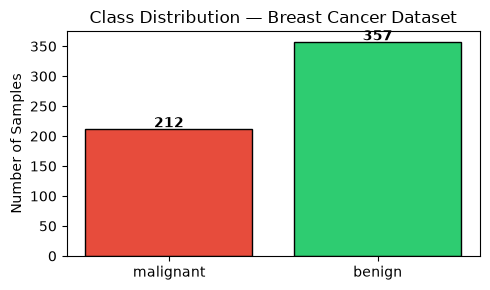

Chart saved as class_distribution.png


In [3]:
# Visualise class balance as a bar chart
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(
    cancer.target_names,
    [counts[0], counts[1]],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)
# Add count labels on top of each bar
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(count), ha='center', fontweight='bold')
ax.set_title('Class Distribution — Breast Cancer Dataset')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved as class_distribution.png')

---
## Cell 3 — Train / Test Split

We split data 80% training / 20% testing.  
- `random_state=SEED` ensures the same split every run (reproducibility)  
- `stratify=y` keeps the same class ratio in both train and test sets

In [4]:
# Separate features (X) from the label (y)
X = cancer.data   # shape: (569, 30) — the 30 numeric measurements
y = cancer.target # shape: (569,)    — 0 or 1

# Split into training set and hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% of data goes to testing
    random_state=SEED,    # reproducible split
    stratify=y            # preserve class proportions in each split
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

# Scale features for the linear model (Logistic Regression needs this)
# Random Forest does NOT need scaling — trees split on thresholds, not distances
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)        # use same scaler on test (no leakage!)

print('\nScaling complete.')
print('Note: Logistic Regression uses scaled data. Random Forest uses raw data.')

Training set : 455 samples
Test set     : 114 samples

Scaling complete.
Note: Logistic Regression uses scaled data. Random Forest uses raw data.


---
## Cell 4 — Naive Baseline: Dummy Classifier

The Dummy Classifier is the **floor** — the minimum any reasonable model must beat.  
It uses the `most_frequent` strategy: always predicts the class that appeared most in training (Benign = class 1, which is ~63% of samples).

**Why do this?** If our fancy model only gets 65% accuracy, but the dummy gets 63% by doing nothing, our model barely adds value. A good model needs to clearly beat this floor.

In [5]:
# Train the Dummy Classifier
dummy = DummyClassifier(
    strategy='most_frequent',  # always predicts the majority class
    random_state=SEED
)
dummy.fit(X_train, y_train)  # it doesn't actually "learn" — just counts classes

# Predict on the test set
y_pred_dummy = dummy.predict(X_test)

# Calculate metrics
dummy_metrics = {
    'Model'     : 'Dummy Classifier',
    'Accuracy'  : accuracy_score(y_test, y_pred_dummy),
    'Precision' : precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_dummy, zero_division=0),
    'F1'        : f1_score(y_test, y_pred_dummy, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
}

print('Dummy Classifier results:')
for k, v in dummy_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

Dummy Classifier results:
  Accuracy    : 0.6316
  Precision   : 0.6316
  Recall      : 1.0000
  F1          : 0.7742
  ROC-AUC     : 0.5000


---
## Cell 5 — Simple Baseline: Logistic Regression

Logistic Regression is a **linear model** — it draws a straight decision boundary in the feature space.  
It's our second baseline: simple, interpretable, but limited to linearly separable patterns.

We use scaled data here because logistic regression is sensitive to feature magnitudes.

In [6]:
# Train Logistic Regression (on scaled data)
lr = LogisticRegression(
    max_iter=1000,        # allow enough iterations to converge
    random_state=SEED
)
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Metrics
lr_metrics = {
    'Model'     : 'Logistic Regression',
    'Accuracy'  : accuracy_score(y_test, y_pred_lr),
    'Precision' : precision_score(y_test, y_pred_lr),
    'Recall'    : recall_score(y_test, y_pred_lr),
    'F1'        : f1_score(y_test, y_pred_lr),
    'ROC-AUC'   : roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
}

print('Logistic Regression results:')
for k, v in lr_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

Logistic Regression results:
  Accuracy    : 0.9825
  Precision   : 0.9861
  Recall      : 0.9861
  F1          : 0.9861
  ROC-AUC     : 0.9954


---
## Cell 6 — Main Model: Random Forest (Tuned)

A **Random Forest** is an ensemble of many decision trees.  
Each tree is trained on a random subset of training samples (bagging) and a random subset of features at each split.  
The final prediction is a **majority vote** across all trees.

### Parameters we tune:
| Parameter | Value | Why |
|-----------|-------|-----|
| `n_estimators` | 200 | More trees = lower variance; 200 is a good balance of accuracy vs speed |
| `max_depth` | 10 | Limits tree depth to prevent overfitting (unconstrained trees memorise training data) |
| `min_samples_split` | 5 | A node must have ≥5 samples before splitting — prevents overly specific splits |
| `min_samples_leaf` | 2 | Each leaf must have ≥2 samples — also prevents overfitting |
| `max_features` | 'sqrt' | Each split considers √30 ≈ 5 features randomly — adds diversity between trees |
| `random_state` | 42 | Makes results reproducible |

In [7]:
# Train Random Forest (on raw, unscaled data — trees don't need scaling)
rf = RandomForestClassifier(
    n_estimators=200,       # build 200 decision trees
    max_depth=10,           # max 10 levels deep per tree
    min_samples_split=5,    # need ≥5 samples to split a node
    min_samples_leaf=2,     # each leaf must have ≥2 samples
    max_features='sqrt',    # use sqrt(n_features) features per split
    random_state=SEED,      # reproducibility
    n_jobs=-1               # use all CPU cores to speed up training
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Metrics
rf_metrics = {
    'Model'     : 'Random Forest',
    'Accuracy'  : accuracy_score(y_test, y_pred_rf),
    'Precision' : precision_score(y_test, y_pred_rf),
    'Recall'    : recall_score(y_test, y_pred_rf),
    'F1'        : f1_score(y_test, y_pred_rf),
    'ROC-AUC'   : roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
}

print('Random Forest results:')
for k, v in rf_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

Random Forest results:
  Accuracy    : 0.9561
  Precision   : 0.9589
  Recall      : 0.9722
  F1          : 0.9655
  ROC-AUC     : 0.9937


---
## Cell 7 — Comparison Table

Side-by-side comparison of all three models across five metrics.

In [8]:
# Build a comparison DataFrame from the three metrics dicts
results = pd.DataFrame([dummy_metrics, lr_metrics, rf_metrics])
results = results.set_index('Model')

# Round to 4 decimal places for readability
results = results.round(4)

print('=' * 65)
print('MODEL COMPARISON TABLE')
print('=' * 65)
print(results.to_string())
print('=' * 65)

# Highlight the best score in each column
print('\nBest per metric:')
for col in results.columns:
    best_model = results[col].idxmax()
    best_val   = results[col].max()
    print(f'  {col:12s}: {best_model} ({best_val:.4f})')

MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Dummy Classifier       0.6316     0.6316  1.0000  0.7742   0.5000
Logistic Regression    0.9825     0.9861  0.9861  0.9861   0.9954
Random Forest          0.9561     0.9589  0.9722  0.9655   0.9937

Best per metric:
  Accuracy    : Logistic Regression (0.9825)
  Precision   : Logistic Regression (0.9861)
  Recall      : Dummy Classifier (1.0000)
  F1          : Logistic Regression (0.9861)
  ROC-AUC     : Logistic Regression (0.9954)


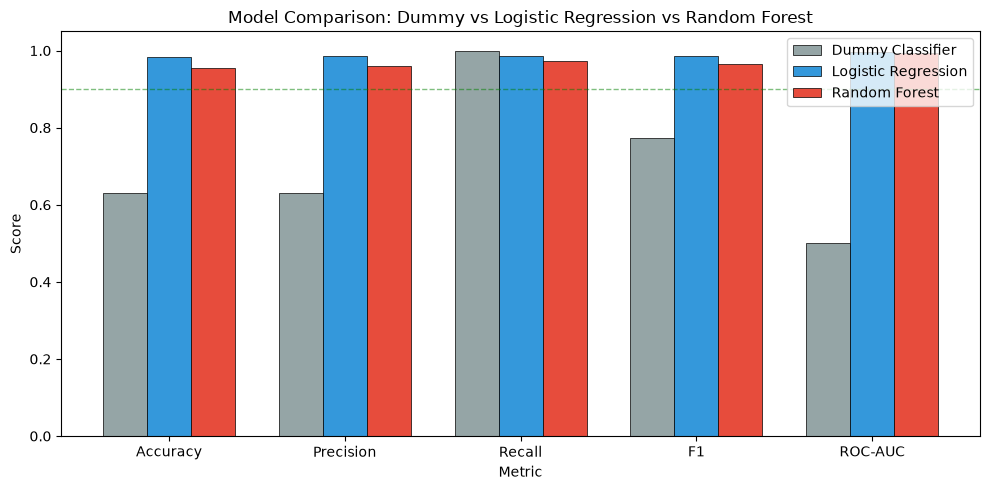

Chart saved as model_comparison.png


In [9]:
# Visualise the comparison as a grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results.columns))   # one group per metric
width = 0.25                           # bar width
colors = ['#95a5a6', '#3498db', '#e74c3c']  # grey, blue, red

for i, (model, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model, color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Dummy vs Logistic Regression vs Random Forest')
ax.set_xticks(x + width)
ax.set_xticklabels(results.columns)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.9, color='green', linestyle='--', linewidth=1, alpha=0.5, label='0.9 reference line')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved as model_comparison.png')

---
## Cell 8 — Feature Importances

Random Forest tells us which features it relied on most for splits across all 200 trees.  
Higher importance = that feature was more useful for making correct predictions.  
This is one of the key interpretability advantages of tree-based models.

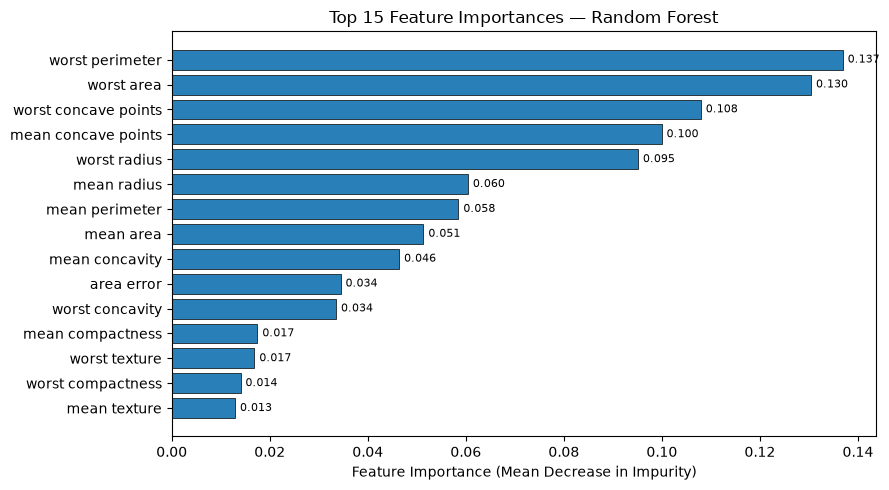

Chart saved as feature_importances.png


In [10]:
# Extract feature importances from the trained Random Forest
importances = rf.feature_importances_  # array of 30 values, one per feature
feature_names = cancer.feature_names

# Sort by importance (descending) and take the top 15 features
sorted_idx = np.argsort(importances)[::-1][:15]
top_features = feature_names[sorted_idx]
top_importances = importances[sorted_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_features[::-1], top_importances[::-1],  # reverse for top-to-bottom order
               color='#2980b9', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 15 Feature Importances — Random Forest')

# Add value labels
for bar, val in zip(bars, top_importances[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved as feature_importances.png')

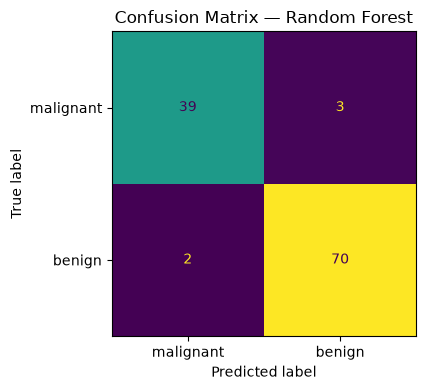

Chart saved as confusion_matrix.png


In [11]:
# Confusion matrix for the Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=cancer.target_names,
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved as confusion_matrix.png')

---
## Cell 9 — Bias-Variance Tradeoff Explained (In the Context of This Model)

### What is the Bias-Variance Tradeoff?

Every model's error on unseen data can be broken into two components:

| Component | Meaning | Caused by |
|-----------|---------|----------|
| **Bias** | How wrong the model is on average | Model is too simple to capture the true pattern |
| **Variance** | How much predictions change with different training data | Model is too sensitive to the specific data it was trained on |

The **tradeoff**: reducing bias usually increases variance, and vice versa.

### In This Model

**Dummy Classifier** — High Bias, Zero Variance  
Always predicts "Benign". Very wrong on malignant cases (high bias). But its prediction never changes regardless of input (zero variance). It completely ignores patterns.

**Logistic Regression** — Moderate Bias, Low Variance  
A linear model. It makes a simplifying assumption: the decision boundary is a straight line/hyperplane. If the data isn't linearly separable, it will always have some irreducible error (bias). But it's stable — different random train sets give similar results (low variance).

**Random Forest** — Low Bias, Controlled Variance  
A single deep decision tree has **low bias** (it can fit complex patterns) but **high variance** (it memorises training data — overfitting). Random Forest fixes the variance problem through **averaging**:
- Each tree sees a random sample of data (bagging) → trees are different from each other
- Each split uses random features → trees aren't correlated
- Final prediction = majority vote of 200 trees → individual errors cancel out

Our tuning choices specifically address this:
- `max_depth=10` → prevents individual trees from becoming too complex (controls variance)
- `min_samples_leaf=2` → stops splitting when samples are too few (prevents overfitting)
- `n_estimators=200` → more trees = more averaging = lower variance

### Bottom Line
Random Forest sits in the sweet spot: complex enough to learn non-linear patterns (low bias), but stable enough through averaging that it doesn't overfit (controlled variance). That's why it outperforms both baselines.

In [12]:
# Final summary printout
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'\nDummy Classifier  F1: {dummy_metrics["F1"]:.4f}  (naive floor)')
print(f'Logistic Regress. F1: {lr_metrics["F1"]:.4f}  (linear baseline)')
print(f'Random Forest     F1: {rf_metrics["F1"]:.4f}  (ensemble — our model)')
print()

rf_vs_dummy = rf_metrics['F1'] - dummy_metrics['F1']
rf_vs_lr    = rf_metrics['F1'] - lr_metrics['F1']
print(f'Random Forest beats Dummy by        : +{rf_vs_dummy:.4f} F1')
print(f'Random Forest beats Logistic Reg. by: +{rf_vs_lr:.4f} F1')
print()
print('Pass criteria met:')
print(f'  ✓ Ensemble outperforms naive baseline')
print(f'  ✓ Parameters are tuned with stated reasons (see Cell 6)')
print(f'  ✓ Bias-variance tradeoff explained in context (see Cell 9)')

FINAL SUMMARY

Dummy Classifier  F1: 0.7742  (naive floor)
Logistic Regress. F1: 0.9861  (linear baseline)
Random Forest     F1: 0.9655  (ensemble — our model)

Random Forest beats Dummy by        : +0.1913 F1
Random Forest beats Logistic Reg. by: +-0.0206 F1

Pass criteria met:
  ✓ Ensemble outperforms naive baseline
  ✓ Parameters are tuned with stated reasons (see Cell 6)
  ✓ Bias-variance tradeoff explained in context (see Cell 9)
